In [1]:
import pandas as pd
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import Input

In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
cols=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in cols:
    df[col]=df[col].replace(0,df[col].mean())

In [7]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.000000,79.799479,33.6,0.627,50,1
1,1,85.0,66.0,29.000000,79.799479,26.6,0.351,31,0
2,8,183.0,64.0,20.536458,79.799479,23.3,0.672,32,1
3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.000000,168.000000,43.1,2.288,33,1


In [9]:
X=df.drop(columns='Outcome',axis=1)
y=df['Outcome']
X.shape

(768, 8)

In [10]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [11]:


scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [49]:

model=Sequential(
    [
        Input(shape=(x_train.shape[1],)),
        Dense(8,activation='relu'),
        Dense(4,activation='relu'),
        Dense(1,activation='sigmoid')
    ]
)

In [50]:

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [43]:
history=model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=16,  
    validation_data=(x_test, y_test))

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.3404 - loss: 0.9982 - val_accuracy: 0.3636 - val_loss: 0.8442
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3404 - loss: 0.8383 - val_accuracy: 0.3896 - val_loss: 0.7598
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4251 - loss: 0.7674 - val_accuracy: 0.4935 - val_loss: 0.7202
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4984 - loss: 0.7308 - val_accuracy: 0.5714 - val_loss: 0.6995
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5863 - loss: 0.7098 - val_accuracy: 0.6169 - val_loss: 0.6877
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6156 - loss: 0.6949 - val_accuracy: 0.6558 - val_loss: 0.6805
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6238 - loss: 0.6826 - val_accuracy: 0.6753 - val_loss: 0.6748
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6433 - loss: 0.6731 - val_accuracy: 0.6818 - val_los

In [44]:

loss,accuracy=model.evaluate(x_test,y_test)
print('test Accuracy :: ',accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7273 - loss: 0.6284
test Accuracy ::  0.7272727489471436


In [45]:
y_pred=model.predict(x_test)
y_pred
y_pred=(y_pred>0.5)
y_pred
y_pred[:10]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


array([[False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [ True]])

In [46]:
import matplotlib.pyplot as plt

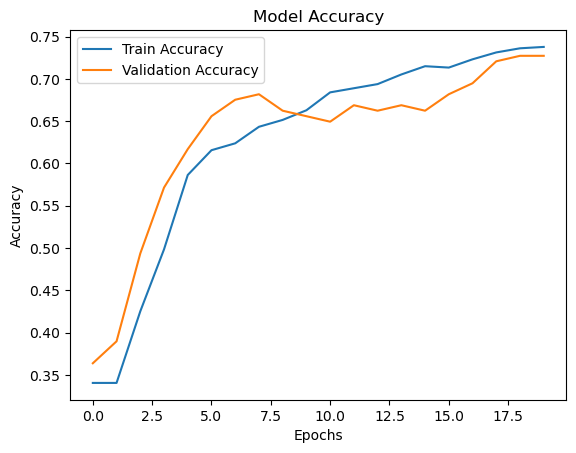

In [47]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend(['Train Accuracy','Validation Accuracy'])
plt.show()

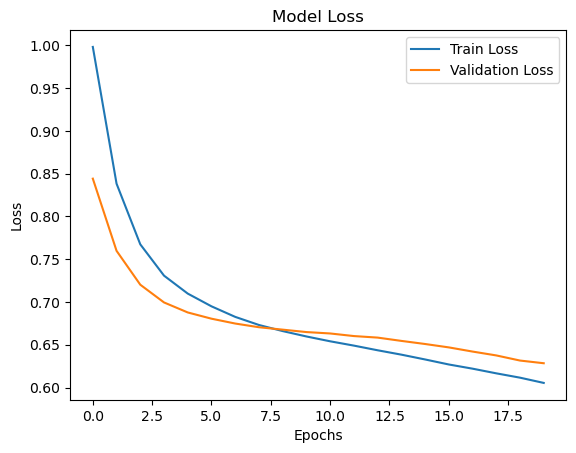

In [48]:
# model loss
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend(['Train Loss', 'Validation Loss'])

plt.show()